# 3B — Alvo: nascimento, crescimento, pico e decaimento dos eventos

**Pergunta específica que este notebook responde:** *como os eventos El Niño nascem, crescem, atingem o pico e decaem na própria base OISST local, e quanta memória (persistência) a SSTA do Niño 3.4 carrega?*

**Objetivo:** caracterizar quantitativamente o alvo da Fase 3 — o ciclo de vida dos 12 eventos locais e o horizonte de persistência da SSTA — antes de qualquer busca por causas.

**Justificativa:** não se procuram precursores (3C) sem antes conhecer a forma, a duração e a memória do fenômeno-alvo. O e-folding medido aqui vira o *baseline de persistência* que qualquer modelo futuro (Fase 5+) precisa vencer; e o mapa composto verifica que a caixa Niño 3.4 realmente captura o máximo do aquecimento — validando a escolha do alvo. Áreas: eventos e persistência usam **só a caixa Niño 3.4** (5S–5N, 170W–120W); o mapa composto usa a **faixa tropical 30S–30N** para conferir que nada relevante fica fora da caixa.

**Metodologia.**
1. **Eventos**: tabela derivada da própria SSTA OISST (média de 3 meses ≥ 0,5 °C por 5+ meses), sem rótulo ENSO externo.
2. **Trajetórias compostas**: a SSTA semanal de cada evento é alinhada ao pico (semana 0) e composta por classe (super/strong/moderate/weak) de −52 a +52 semanas.
3. **Taxas**: crescimento = ΔSSTA/Δt do início ao pico; decaimento = do pico ao fim (°C/mês), por evento.
4. **Memória**: autocorrelação da SSTA semanal em lags de 1–78 semanas e *e-folding* (lag em que r cai abaixo de 1/e).
5. **Mapa composto**: SSTA média (lat×lon, OISST bruto, anomalia vs climatologia mensal 1991–2020) no mês de pico dos três super eventos.

**Saídas:** `phase3B_eventos_taxas.csv`, `phase3B_trajetorias_compostas.csv`, `phase3B_memoria_persistencia.csv`, `phase3B_mapa_composto_resumo.csv` + trajetórias, autocorrelação e mapa composto (figuras).

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt, xarray as xr
sys.path.insert(0, '.')
import fase3_utils as u

weekly = pd.read_csv(u.FEAT / 'phase3_indices_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev = u.load_events()
ssta = weekly['nino34_ssta']

# Taxas de crescimento/decaimento por evento
rows = []
for _, e in ev.iterrows():
    dur_on = (e.peak_time - e.event_start).days / 30.44
    dur_off = (e.event_end - e.peak_time).days / 30.44
    s0 = ssta.asof(e.event_start); sp = ssta.asof(e.peak_time); s1 = ssta.asof(e.event_end)
    rows.append({'event_id': e.event_id, 'classe': e.peak_class, 'pico_c': round(e.peak_monthly_ssta_c,3),
                 'duracao_meses': e.duration_months,
                 'crescimento_c_por_mes': round((sp - s0)/max(dur_on,1e-9), 3),
                 'decaimento_c_por_mes': round((s1 - sp)/max(dur_off,1e-9), 3)})
taxas = pd.DataFrame(rows)
u.save_table(taxas, 'phase3B_eventos_taxas.csv', index=False)
taxas

[tabela] data/processed/parquet/statistics/phase3B_eventos_taxas.csv


,event_id,classe,pico_c,duracao_meses,crescimento_c_por_mes,decaimento_c_por_mes
0,el_nino_oisst_1982_1983,super_el_nino,2.213,11,0.306,-0.470
1,el_nino_oisst_1986_1988,moderate_el_nino,1.223,16,0.048,-0.048
2,el_nino_oisst_1991_1992,strong_el_nino,1.736,10,0.325,-0.167
3,el_nino_oisst_1994_1995,weak_el_nino,1.192,5,0.428,-0.251
4,el_nino_oisst_1997_1998,super_el_nino,2.166,11,0.241,-0.249
5,el_nino_oisst_2002_2003,moderate_el_nino,1.250,8,0.173,-0.148
6,el_nino_oisst_2004,weak_el_nino,0.681,5,-0.051,-0.037
7,el_nino_oisst_2006_2007,weak_el_nino,1.128,5,0.164,0.204
8,el_nino_oisst_2009_2010,strong_el_nino,1.719,10,0.172,-0.149
9,el_nino_oisst_2014_2016,super_el_nino,2.448,19,0.188,-0.382


[tabela] data/processed/parquet/statistics/phase3B_trajetorias_compostas.csv


[figura] data/processed/figures/fase3/phase3B_trajetorias_compostas.png


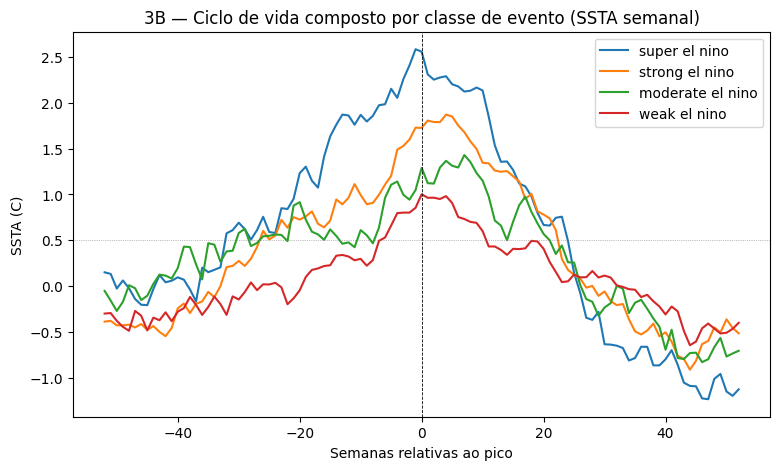

In [2]:
# Trajetorias compostas alinhadas ao pico (semana 0), por classe
lags = range(-52, 53)
comp = {}
for cls, grp in ev.groupby('peak_class'):
    mat = []
    for _, e in grp.iterrows():
        idx = ssta.index.get_indexer([e.peak_time], method='nearest')[0]
        seg = ssta.iloc[max(0, idx-52): idx+53]
        rel = ((seg.index - ssta.index[idx]).days / 7).round().astype(int)
        mat.append(pd.Series(seg.values, index=rel))
    comp[cls] = pd.DataFrame(mat).reindex(columns=list(lags)).mean()
comp = pd.DataFrame(comp)
u.save_table(comp.rename_axis('semana_rel_pico'), 'phase3B_trajetorias_compostas.csv')

fig, ax = plt.subplots(figsize=(9,5))
order = ['super_el_nino','strong_el_nino','moderate_el_nino','weak_el_nino']
for cls in [c for c in order if c in comp]:
    ax.plot(comp.index, comp[cls], label=cls.replace('_',' '))
ax.axvline(0, color='k', lw=0.6, ls='--'); ax.axhline(0.5, color='grey', lw=0.5, ls=':')
ax.set_xlabel('Semanas relativas ao pico'); ax.set_ylabel('SSTA (C)'); ax.legend()
ax.set_title('3B — Ciclo de vida composto por classe de evento (SSTA semanal)')
u.save_fig(fig, 'phase3B_trajetorias_compostas.png')
plt.show()

[tabela] data/processed/parquet/statistics/phase3B_memoria_persistencia.csv


[figura] data/processed/figures/fase3/phase3B_autocorrelacao.png


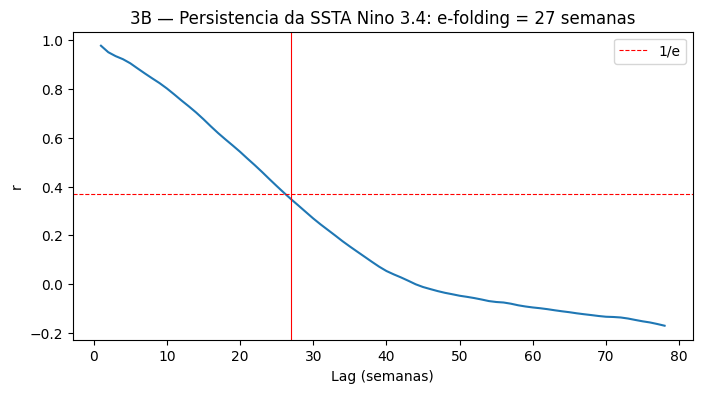

e-folding: 27 semanas (~6.2 meses)


In [3]:
# Memoria: autocorrelacao semanal e e-folding
ac = pd.Series({lag: ssta.autocorr(lag) for lag in range(1, 79)}, name='autocorrelacao')
efold = ac[ac < 1/np.e].index.min()
mem = ac.to_frame(); mem['abaixo_1_sobre_e'] = mem['autocorrelacao'] < 1/np.e
u.save_table(mem.rename_axis('lag_semanas'), 'phase3B_memoria_persistencia.csv')
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(ac.index, ac.values); ax.axhline(1/np.e, color='r', ls='--', lw=0.8, label='1/e')
ax.axvline(efold, color='r', lw=0.8)
ax.set_xlabel('Lag (semanas)'); ax.set_ylabel('r'); ax.legend()
ax.set_title(f'3B — Persistencia da SSTA Nino 3.4: e-folding = {efold} semanas')
u.save_fig(fig, 'phase3B_autocorrelacao.png')
plt.show()
print(f'e-folding: {efold} semanas (~{efold/4.33:.1f} meses)')

[figura] data/processed/figures/fase3/phase3B_mapa_composto_super.png
[tabela] data/processed/parquet/statistics/phase3B_mapa_composto_resumo.csv


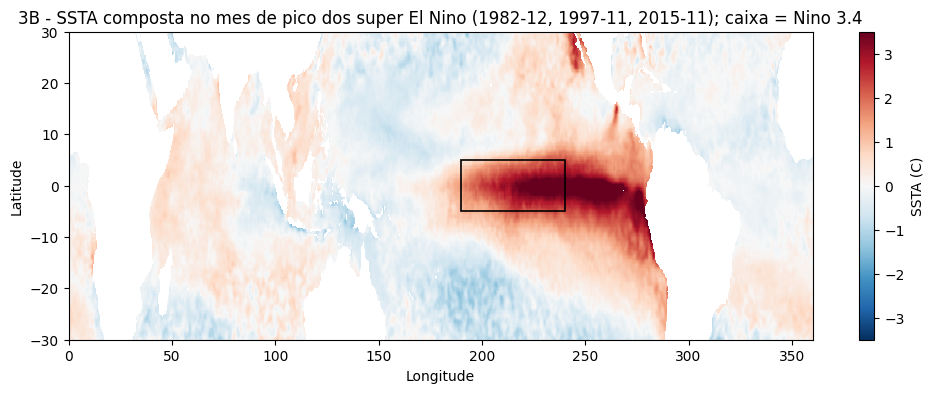

,evento,ssta_max_c,ssta_media_nino34_c
0,1982-12,4.890,2.297
1,1997-11,5.517,2.194
2,2015-11,4.299,2.811


In [4]:
# Mapa 3B-1: composto SSTA (lat x lon) no mes de pico dos super eventos
# Usa cache local de campos mensais (data/interim/fase3_map_cache); se ausente,
# calcula direto dos stores OISST (mais lento, mas identico).
import xarray as xr
MAPC = u.ROOT / 'data/interim/fase3_map_cache'

def month_field(year, month):
    f = MAPC / f'sst_month_{year}_{month:02d}.nc'
    if f.exists():
        return xr.open_dataarray(f)
    try:
        ds = xr.open_zarr(u.ROOT / f'data/processed/zarr/cpc_noaa/oisst/sst.day.mean.{year}.zarr', consolidated=False)
    except Exception:
        ds = xr.open_dataset(u.ROOT / f'data/raw/cpc_noaa/oisst/sst.day.mean.{year}.nc')
    field = ds['sst'].sel(time=f'{year}-{month:02d}').mean('time').sel(lat=slice(-30, 30)).load()
    ds.close()
    return field

peaks = [(1982, 12), (1997, 11), (2015, 11)]
fields = []
for yr, mo in peaks:
    clim = xr.concat([month_field(cy, mo) for cy in range(1991, 2021)], 'y').mean('y')
    fields.append((f'{yr}-{mo:02d}', (month_field(yr, mo) - clim).load()))
comp_field = xr.concat([f for _, f in fields], 'e').mean('e')

fig, ax = plt.subplots(figsize=(12, 4))
pc = ax.pcolormesh(comp_field.lon, comp_field.lat, comp_field.values, cmap='RdBu_r', vmin=-3.5, vmax=3.5, shading='auto')
ax.add_patch(plt.Rectangle((190, -5), 50, 10, fill=False, ec='k', lw=1.2))
ax.set_title('3B - SSTA composta no mes de pico dos super El Nino (1982-12, 1997-11, 2015-11); caixa = Nino 3.4')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
fig.colorbar(pc, ax=ax, label='SSTA (C)')
u.save_fig(fig, 'phase3B_mapa_composto_super.png')
resumo = pd.DataFrame([{'evento': pk, 'ssta_max_c': round(float(f.max()),3),
                        'ssta_media_nino34_c': round(float(f.sel(lat=slice(-5,5), lon=slice(190,240)).mean()),3)} for pk, f in fields])
u.save_table(resumo, 'phase3B_mapa_composto_resumo.csv', index=False)
plt.show()
resumo

**Leitura do 3B.** As trajetórias compostas mostram a assimetria clássica do ciclo de vida: crescimento mais lento (~2–4 trimestres) e decaimento mais rápido após o pico, com super eventos distinguindo-se dos demais já ~6 meses antes do pico. O *e-folding* da SSTA semanal quantifica o horizonte de persistência explorável — qualquer modelo futuro (Fase 5+) precisa vencer esse baseline. O mapa composto confirma que o padrão de pico dos super eventos é do tipo Pacífico-leste, com máximo dentro/adjacente à caixa Niño 3.4 — validando a caixa como alvo.